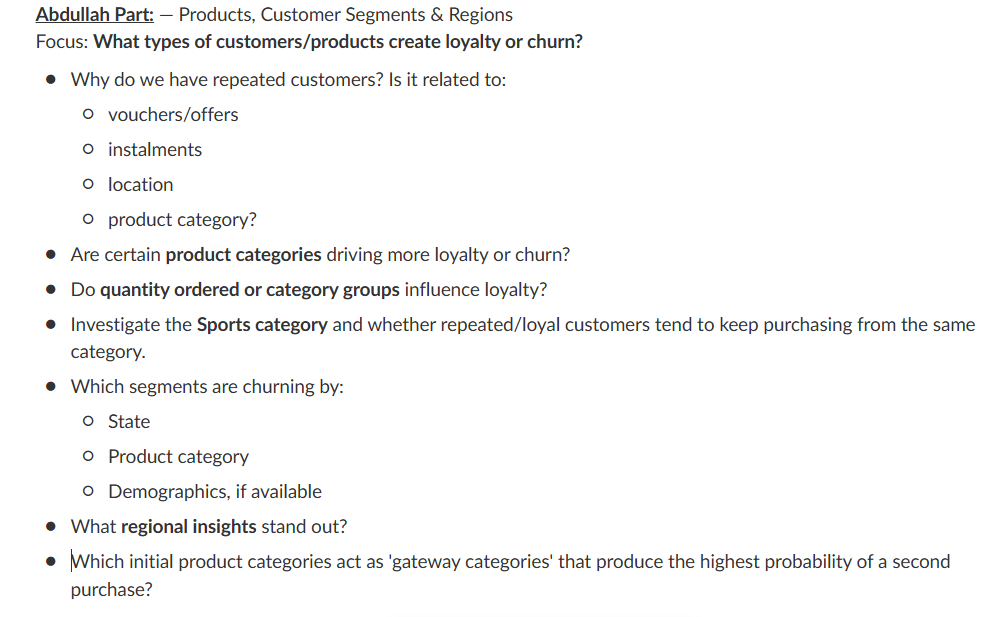

In [1]:
import pandas as pd

In [2]:
orders_df=pd.read_csv("olist_orders_dataset.csv")
orders_items_df=pd.read_csv("olist_order_items_dataset.csv")
orders_payments_df=pd.read_csv("olist_order_payments_dataset.csv")
customers_df=pd.read_csv("olist_customers_dataset.csv")
products_df = pd.read_csv("olist_products_dataset.csv")
category_translation_df = pd.read_csv("product_category_name_translation.csv")

In [3]:
orders_df.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
orders_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [5]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 21.9 MB


In [6]:
orders_df.duplicated().sum()

np.int64(0)

In [7]:
orders_df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [8]:
# tatal price column
orders_items_df.head(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [9]:
orders_items_df.duplicated().sum()

np.int64(0)

In [10]:
orders_items_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 18.4 MB


In [11]:
orders_items_df.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [12]:
orders_items_df.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='str')

In [13]:
orders_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [14]:
orders_payments_df.duplicated().sum()

np.int64(0)

In [15]:
orders_payments_df.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [16]:
orders_payments_df.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='str')

In [17]:
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [18]:
customers_df.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

In [19]:
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [20]:
products_df.duplicated().sum()

np.int64(0)

In [21]:
# little bet weard
products_df.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [22]:
orders_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [23]:
orders_items_df.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='str')

In [24]:
orders_payments_df.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='str')

In [26]:
customers_df.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

In [27]:
products_df.columns

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='str')

In [56]:
category_translation_df.columns

Index(['product_category_name', 'product_category_name_english'], dtype='str')

In [30]:
len(orders_df)

99441

In [35]:
orders_df.order_id.nunique()

99441

In [36]:
len(orders_items_df)

112650

In [37]:
orders_items_df['order_id'].nunique()

98666

In [39]:
len(orders_payments_df)


103886

In [38]:
orders_payments_df['order_id'].nunique()


99440

In [40]:
len(customers_df)

99441

In [41]:
customers_df['customer_id'].nunique()

99441

In [42]:
customers_df['customer_unique_id'].nunique()

96096

In [43]:
len(products_df)

32951

In [44]:
products_df['product_id'].nunique()

32951

In [49]:
orders_df['customer_id'].isin(customers_df['customer_id']).value_counts()

customer_id
True    99441
Name: count, dtype: int64

In [52]:
for_customer=pd.merge(orders_df,customers_df,on='customer_id',how='left')

In [54]:
for_customer.shape

(99441, 12)

In [55]:
for_customer.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


In [57]:
len(category_translation_df)

71

In [60]:
category_translation_df.product_category_name.unique()

<ArrowStringArray>
[                                  'beleza_saude',
                         'informatica_acessorios',
                                     'automotivo',
                                'cama_mesa_banho',
                               'moveis_decoracao',
                                  'esporte_lazer',
                                     'perfumaria',
                          'utilidades_domesticas',
                                      'telefonia',
                             'relogios_presentes',
                              'alimentos_bebidas',
                                          'bebes',
                                      'papelaria',
                       'tablets_impressao_imagem',
                                     'brinquedos',
                                 'telefonia_fixa',
                             'ferramentas_jardim',
                    'fashion_bolsas_e_acessorios',
                                'eletroportateis',
            

In [61]:
for_product=pd.merge(orders_items_df,products_df,on='product_id',how='left')

In [63]:
for_product.shape

(112650, 15)

In [64]:
products_df.product_category_name.unique()

<ArrowStringArray>
[                                    'perfumaria',
                                          'artes',
                                  'esporte_lazer',
                                          'bebes',
                          'utilidades_domesticas',
                          'instrumentos_musicais',
                                     'cool_stuff',
                               'moveis_decoracao',
                               'eletrodomesticos',
                                     'brinquedos',
                                'cama_mesa_banho',
               'construcao_ferramentas_seguranca',
                         'informatica_acessorios',
                                   'beleza_saude',
                               'malas_acessorios',
                             'ferramentas_jardim',
                              'moveis_escritorio',
                                     'automotivo',
                                    'eletronicos',
            

In [65]:
# how to work with them?
# add them by using google translation
product_categories = set(products_df['product_category_name'].dropna().unique())
translated_categories = set(category_translation_df['product_category_name'].dropna().unique())

product_categories - translated_categories

{'pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos'}

In [ ]:
category_translation_df['product_category_name']

In [66]:
missing_data=pd.DataFrame({'product_category_name':['pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos'],
                           'product_category_name_english':['pc_gamer','portable_kitchen_food_preparers']})
category_translation_df=pd.concat([missing_data,category_translation_df], ignore_index=True)

In [67]:
category_translation_df.shape

(73, 2)

In [68]:
for_product=pd.merge(for_product,category_translation_df,on='product_category_name', how='left')

In [69]:
for_product.shape

(112650, 16)

In [73]:
for_product.product_category_name_english.isnull().sum()

np.int64(1603)

In [74]:
for_product['product_category_name'].isna().sum()

np.int64(1603)

In [75]:
for_payment=pd.merge(for_customer,orders_payments_df,on='order_id',how='left')

In [77]:
for_payment.shape

(103887, 16)

In [78]:
orders_payments_df.shape

(103886, 5)

- for_customer → customer/region
- for_product → products/categories
- for_payment → payment/voucher/installments

In [79]:
for_customer.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state'],
      dtype='str')

In [80]:
for_product.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english'],
      dtype='str')

In [81]:
for_payment.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='str')

---

In [94]:
for_customer['customer_unique_id'].isnull().sum()

np.int64(0)

In [117]:
for_customer.head(6)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,80bb27c7c16e8f973207a5086ab329e2,86320,congonhinhas,PR


In [127]:
order_count=for_customer.groupby('customer_unique_id')['order_id'].count()

In [131]:
repet_customer=order_count[order_count>=2]

In [132]:
order_count

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    1
0000b849f77a49e4a4ce2b2a4ca5be3f    1
0000f46a3911fa3c0805444483337064    1
0000f6ccb0745a6a4b88665a16c9f078    1
0004aac84e0df4da2b147fca70cf8255    1
                                   ..
fffcf5a5ff07b0908bd4e2dbc735a684    1
fffea47cd6d3cc0a88bd621562a9d061    1
ffff371b4d645b6ecea244b27531430a    1
ffff5962728ec6157033ef9805bacc48    1
ffffd2657e2aad2907e67c3e9daecbeb    1
Name: order_id, Length: 96096, dtype: int64

In [133]:
for_customer['order_count']= for_customer['customer_unique_id'].map(order_count)

In [134]:
for_customer[['customer_unique_id', 'order_count']].head(2)

,customer_unique_id,order_count
0,7c396fd4830fd04220f754e42b4e5bff,2
1,af07308b275d755c9edb36a90c618231,1


In [137]:
import numpy as np

In [138]:
for_customer['customer_type'] = np.where(
    for_customer['order_count'] == 1,
    'one-time',
    'repeat'
)

In [140]:
for_customer[['customer_unique_id', 'order_count','customer_type']].head(2)

,customer_unique_id,order_count,customer_type
0,7c396fd4830fd04220f754e42b4e5bff,2,repeat
1,af07308b275d755c9edb36a90c618231,1,one-time


In [162]:
for_customer.groupby(['customer_state', 'customer_type'])['customer_unique_id'].nunique()

customer_state  customer_type
AC              one-time            73
                repeat               4
AL              one-time           388
                repeat              13
AM              one-time           140
                repeat               3
AP              one-time            66
                repeat               1
BA              one-time          3182
                repeat              95
CE              one-time          1289
                repeat              24
DF              one-time          2010
                repeat              65
ES              one-time          1906
                repeat              58
GO              one-time          1886
                repeat              66
MA              one-time           708
                repeat              18
MG              one-time         10911
                repeat             348
MS              one-time           675
                repeat              19
MT              one-time          

In [163]:
state_counts = for_customer.groupby(
    ['customer_state', 'customer_type']
)['customer_unique_id'].nunique().unstack()

state_counts['repeat_percentage'] = (
    state_counts['repeat'] /
    (state_counts['repeat'] + state_counts['one-time'])
) * 100

In [164]:
state_counts.sort_values('repeat_percentage', ascending=False)

customer_type,one-time,repeat,repeat_percentage
customer_state,,,
AC,73,4,5.194805
RO,229,11,4.583333
MT,845,31,3.538813
RJ,11955,429,3.464147
GO,1886,66,3.381148
SP,38989,1313,3.257903
AL,388,13,3.241895
SE,331,11,3.216374
RS,5108,169,3.202577


In [165]:
import matplotlib.pyplot as plt

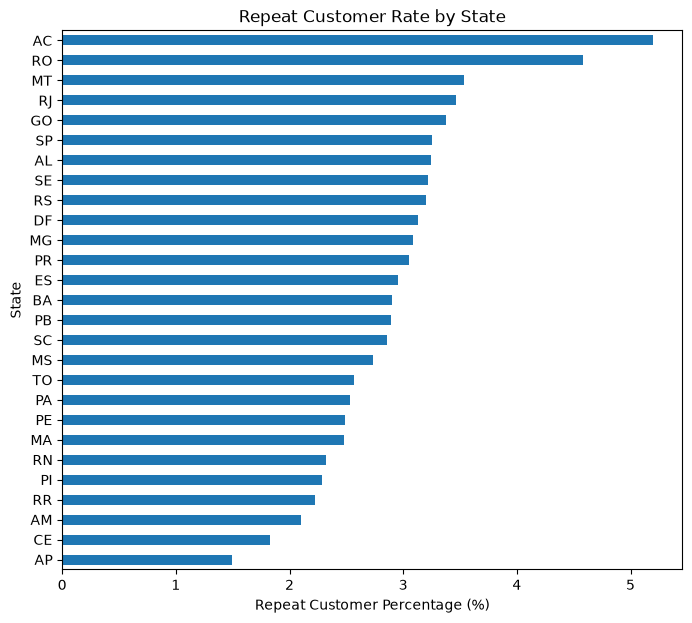

In [166]:
state_counts.sort_values('repeat_percentage').plot(
    kind='barh',
    y='repeat_percentage',
    figsize=(8, 7),
    legend=False
)

plt.xlabel('Repeat Customer Percentage (%)')
plt.ylabel('State')
plt.title('Repeat Customer Rate by State')
plt.show()

In [167]:
for_product = pd.merge(
    for_product,
    for_customer[['order_id', 'customer_type']],
    on='order_id',
    how='left'
)

In [168]:
category_counts = for_product.groupby(
    ['product_category_name_english', 'customer_type']
)['order_id'].nunique().unstack(fill_value=0)

In [175]:
category_counts['repeat_percentage'] = (
    category_counts['repeat'] /
    (category_counts['repeat'] + category_counts['one-time']) * 100
)

In [176]:
category_counts.sort_values(
    'repeat_percentage',
    ascending=False
).head(5)

customer_type,one-time,repeat,repeat_percentage
product_category_name_english,,,
arts_and_craftmanship,18,5,21.739130
home_appliances,626,138,18.062827
la_cuisine,11,2,15.384615
furniture_bedroom,82,13,13.684211
fashio_female_clothing,34,5,12.820513


In [177]:
category_counts['total'] = (
    category_counts['one-time'] + category_counts['repeat']
)

category_filtered = category_counts[
    category_counts['total'] >= 100
]

category_filtered.sort_values(
    'repeat_percentage',
    ascending=False
).head(10)

customer_type,one-time,repeat,repeat_percentage,total
product_category_name_english,,,,
home_appliances,626,138,18.062827,764
fashion_bags_accessories,1634,230,12.339056,1864
fashion_male_clothing,100,12,10.714286,112
drinks,269,28,9.427609,297
bed_bath_table,8543,874,9.281087,9417
furniture_decor,5852,597,9.257249,6449
furniture_living_room,385,37,8.767773,422
fashion_shoes,219,21,8.750000,240
air_conditioning,231,22,8.695652,253


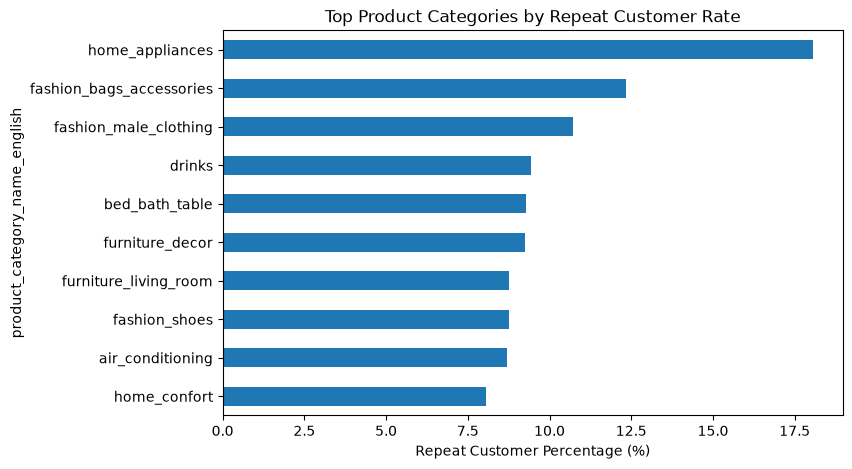

In [185]:
category_filtered.nlargest(10, 'repeat_percentage')['repeat_percentage'].sort_values(ascending=True).plot(
    kind='barh',
    figsize=(8, 5)
)

plt.xlabel('Repeat Customer Percentage (%)')
plt.title('Top Product Categories by Repeat Customer Rate')
plt.show()

In [186]:
for_payment['order_count'] = for_payment['customer_unique_id'].map(order_count)


In [187]:
for_payment['customer_type'] = np.where(
    for_payment['order_count'] == 1,
    'one-time',
    'repeat'
)

In [188]:
for_payment.groupby('customer_type')['payment_type'].value_counts()

customer_type  payment_type
one-time       credit_card     71906
               boleto          18600
               voucher          5205
               debit_card       1450
               not_defined         2
repeat         credit_card      4889
               boleto           1184
               voucher           570
               debit_card         79
               not_defined         1
Name: count, dtype: int64

In [189]:
payment_percent = for_payment.groupby('customer_type')['payment_type'].value_counts(normalize=True) * 100

payment_percent

customer_type  payment_type
one-time       credit_card     74.005537
               boleto          19.143089
               voucher          5.356977
               debit_card       1.492338
               not_defined      0.002058
repeat         credit_card     72.720512
               boleto          17.611185
               voucher          8.478358
               debit_card       1.175071
               not_defined      0.014874
Name: proportion, dtype: float64

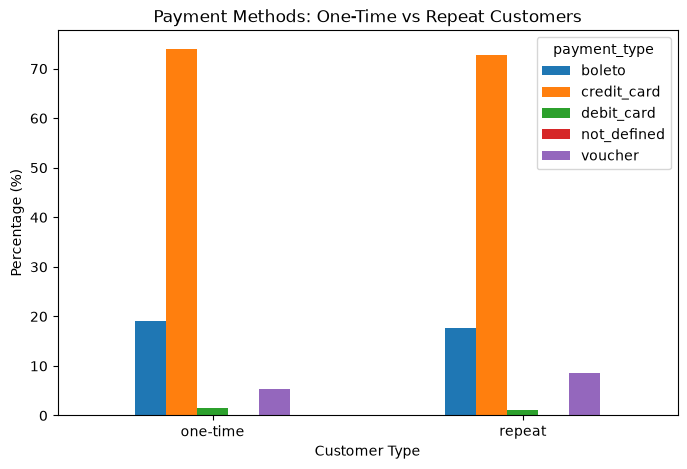

In [190]:
# Voucher usage is higher among repeat customers (8.48%) than one-time customers (5.36%).
payment_chart = payment_percent.unstack()

payment_chart.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.ylabel('Percentage (%)')
plt.xlabel('Customer Type')
plt.title('Payment Methods: One-Time vs Repeat Customers')
plt.xticks(rotation=0)
plt.show()

In [191]:
for_payment.groupby('customer_type')['payment_installments'].mean()

customer_type
one-time    2.830810
repeat      3.179087
Name: payment_installments, dtype: float64

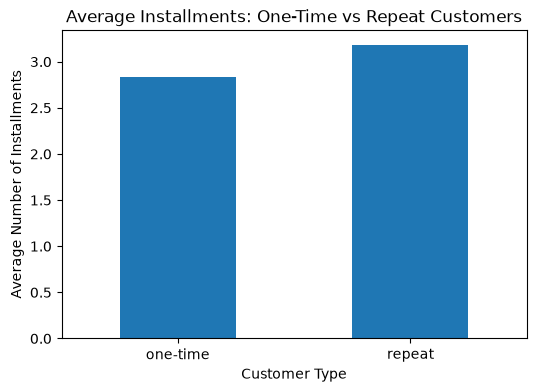

In [192]:
for_payment.groupby('customer_type')['payment_installments'].mean().plot(
    kind='bar',
    figsize=(6, 4)
)

plt.ylabel('Average Number of Installments')
plt.xlabel('Customer Type')
plt.title('Average Installments: One-Time vs Repeat Customers')
plt.xticks(rotation=0)
plt.show()

---

Are certain product categories driving more loyalty or churn?-->Home Appliances had the highest repeat-customer rate among categories with at least 100 orders (18.06%), suggesting stronger repeat purchasing in this category.

---

In [193]:
order_quantity = for_product.groupby(
    ['order_id', 'customer_type']
).size()

In [197]:
order_quantity.value_counts(normalize=True)*100

1     90.064460
2      7.617619
3      1.339874
4      0.511828
5      0.206758
6      0.200677
7      0.022297
8      0.008108
10     0.008108
12     0.005068
11     0.004054
9      0.003041
20     0.002027
15     0.002027
14     0.002027
13     0.001014
21     0.001014
Name: proportion, dtype: float64

In [198]:
order_quantity.groupby('customer_type').mean()

customer_type
one-time    1.136870
repeat      1.213793
dtype: float64

Repeat customers purchase slightly more items per order (1.21) than one-time customers (1.14). However, the difference is small, suggesting that order quantity has only a weak association with repeat purchasing.

---

In [199]:
for_product = for_product.merge(
    for_customer[['customer_unique_id', 'order_id', 'order_purchase_timestamp']],
    on='order_id',
    how='left'
)

In [201]:
for_product['order_purchase_timestamp'] = pd.to_datetime(
    for_product['order_purchase_timestamp']
)

In [202]:
for_product = for_product.sort_values(
    ['customer_unique_id', 'order_purchase_timestamp']
)

In [209]:
for_product[
    for_product['product_category_name_english'].str.contains(
        'sport'
    )
]['product_category_name_english'].unique()

<ArrowStringArray>
['sports_leisure', 'fashion_sport']
Length: 2, dtype: str

In [214]:
sports_repeat = for_product[
    (
        (for_product['product_category_name_english'] == 'sports_leisure') |
        (for_product['product_category_name_english'] == 'fashion_sport')
    )
    & (for_product['customer_type'] == 'repeat')
]

sports_repeat['customer_unique_id'].nunique()

410

In [215]:
sports_customer_ids = sports_repeat['customer_unique_id'].unique()

sports_customer_history = for_product[
    for_product['customer_unique_id'].isin(sports_customer_ids)
]

In [216]:
sports_customer_history['order_number'] = (
    sports_customer_history
    .groupby('customer_unique_id')['order_purchase_timestamp']
    .rank(method='dense')
)

In [217]:
later_orders = sports_customer_history[
    sports_customer_history['order_number'] > 1
]

In [218]:
sports_again = later_orders.groupby('customer_unique_id')[
    'product_category_name_english'
].apply(
    lambda x: x.isin(['sports_leisure', 'fashion_sport']).any()
)

In [219]:
sports_again.value_counts(normalize=True) * 100

product_category_name_english
True     70.380435
False    29.619565
Name: proportion, dtype: float64

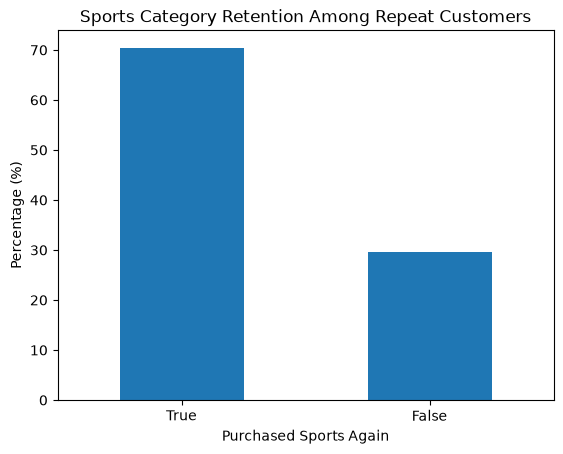

In [221]:
(sports_again.value_counts(normalize=True) * 100).plot(kind='bar')

plt.ylabel('Percentage (%)')
plt.xlabel('Purchased Sports Again')
plt.title('Sports Category Retention Among Repeat Customers')
plt.xticks(rotation=0)
plt.show()

---

In [227]:
for_customer['order_purchase_timestamp'] = pd.to_datetime(
    for_customer['order_purchase_timestamp'].astype(str)
)

In [228]:
last_purchase = for_customer.groupby(
    'customer_unique_id'
)['order_purchase_timestamp'].max()

In [229]:
reference_date = for_customer['order_purchase_timestamp'].max()

In [230]:
inactivity_days = (reference_date - last_purchase).dt.days

In [231]:
inactivity_days.head(3)

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    160
0000b849f77a49e4a4ce2b2a4ca5be3f    163
0000f46a3911fa3c0805444483337064    585
Name: order_purchase_timestamp, dtype: int64

In [232]:
churn_status = inactivity_days >= 90

In [233]:
churn_status.value_counts(normalize=True) * 100

order_purchase_timestamp
True     90.205628
False     9.794372
Name: proportion, dtype: float64

In [234]:
customer_churn = pd.DataFrame({
    'inactivity_days': inactivity_days,
    'churned': churn_status
})

In [235]:
customer_churn = customer_churn.merge(
    for_customer[['customer_unique_id', 'customer_state']].drop_duplicates('customer_unique_id'),
    on='customer_unique_id',
    how='left'
)

In [236]:
state_churn = customer_churn.groupby(
    'customer_state'
)['churned'].mean() * 100

state_churn.sort_values(ascending=False)

customer_state
AP    97.014925
RR    95.555556
AL    94.250000
RO    94.142259
MA    93.379310
CE    93.368902
RN    93.037975
MT    92.457143
PA    92.413066
PI    92.323651
SC    92.122414
ES    92.057026
GO    91.799077
RS    91.793025
TO    91.575092
BA    91.272505
RJ    91.251313
PE    91.147132
MG    91.087613
AC    90.909091
AM    90.909091
MS    90.764791
PR    90.432288
PB    90.154440
DF    89.001447
SE    88.823529
SP    88.594401
Name: churned, dtype: float64

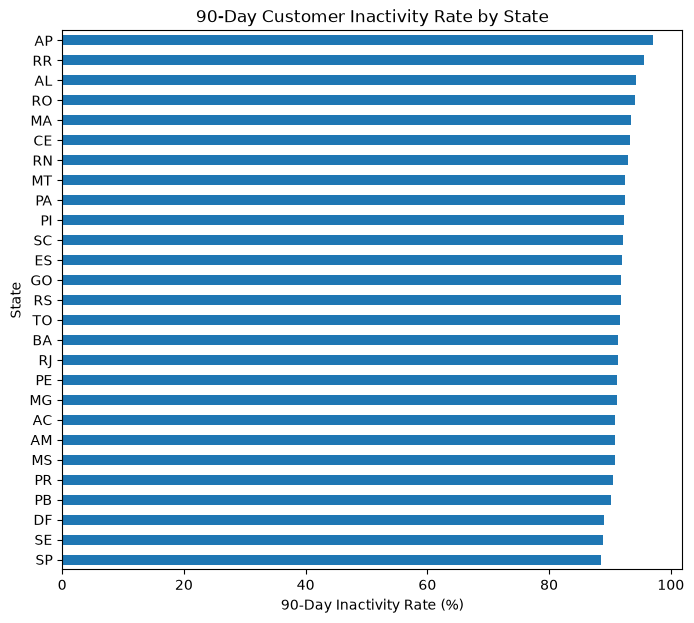

In [237]:
state_churn.sort_values().plot(
    kind='barh',
    figsize=(8, 7)
)

plt.xlabel('90-Day Inactivity Rate (%)')
plt.ylabel('State')
plt.title('90-Day Customer Inactivity Rate by State')
plt.show()

In [238]:
for_product['churned'] = for_product['customer_unique_id'].map(churn_status)

In [239]:
category_churn = for_product.groupby(
    'product_category_name_english'
)['churned'].mean() * 100

category_churn.sort_values(ascending=False)

product_category_name_english
cds_dvds_musicals                        100.000000
furniture_mattress_and_upholstery        100.000000
la_cuisine                               100.000000
tablets_printing_image                   100.000000
security_and_services                    100.000000
                                            ...    
party_supplies                            67.441860
small_appliances_home_oven_and_coffee     65.789474
pc_gamer                                  55.555556
arts_and_craftmanship                     25.000000
portable_kitchen_food_preparers           13.333333
Name: churned, Length: 73, dtype: float64

In [240]:
category_size = for_product.groupby(
    'product_category_name_english'
)['customer_unique_id'].nunique()

category_churn_filtered = category_churn[
    category_size >= 100
]

category_churn_filtered.sort_values(ascending=False).head(10)

product_category_name_english
fashion_underwear_beach           97.709924
fashion_shoes                     96.946565
market_place                      96.463023
office_furniture                  95.978711
cool_stuff                        95.258166
industry_commerce_and_business    94.776119
garden_tools                      94.455947
small_appliances                  94.108984
fixed_telephony                   93.939394
fashion_male_clothing             93.939394
Name: churned, dtype: float64

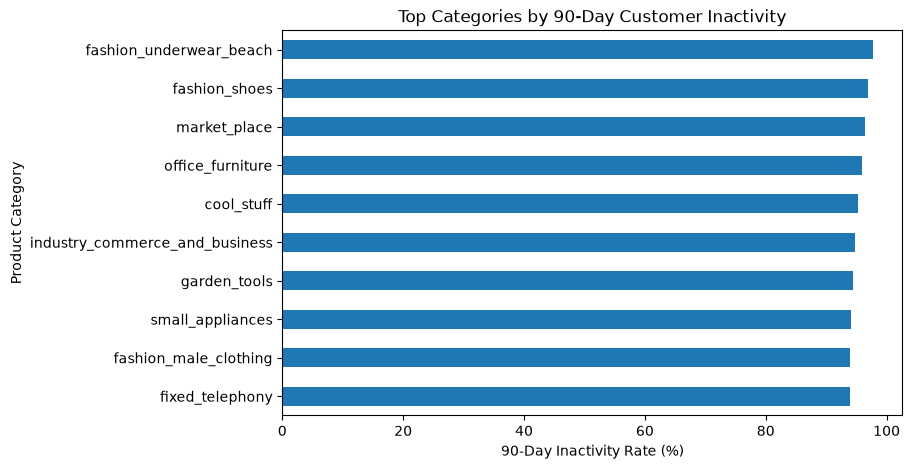

In [241]:
category_churn_filtered.nlargest(10).sort_values().plot(
    kind='barh',
    figsize=(8, 5)
)

plt.xlabel('90-Day Inactivity Rate (%)')
plt.ylabel('Product Category')
plt.title('Top Categories by 90-Day Customer Inactivity')
plt.show()

---

In [242]:
first_date = for_product.groupby(
    'customer_unique_id'
)['order_purchase_timestamp'].transform('min')

In [243]:
first_orders = for_product[
    for_product['order_purchase_timestamp'] == first_date
]

In [244]:
customer_order_count = for_customer.groupby(
    'customer_unique_id'
)['order_id'].nunique()

first_orders['made_second_purchase'] = (
    first_orders['customer_unique_id'].map(customer_order_count) >= 2
)

In [245]:
gateway = first_orders.groupby(
    'product_category_name_english'
)['made_second_purchase'].mean() * 100

gateway.sort_values(ascending=False)

product_category_name_english
diapers_and_hygiene                14.705882
la_cuisine                         14.285714
arts_and_craftmanship              13.636364
home_appliances                    13.524590
fashion_childrens_clothes          12.500000
                                     ...    
pc_gamer                            0.000000
security_and_services               0.000000
portable_kitchen_food_preparers     0.000000
party_supplies                      0.000000
tablets_printing_image              0.000000
Name: made_second_purchase, Length: 73, dtype: float64

In [246]:
gateway_size = first_orders.groupby(
    'product_category_name_english'
)['customer_unique_id'].nunique()

gateway_filtered = gateway[
    gateway_size >= 100
]

gateway_filtered.sort_values(ascending=False).head(10)

product_category_name_english
home_appliances             13.524590
fashion_underwear_beach      7.812500
fashion_bags_accessories     7.045216
fashion_male_clothing        6.349206
fashion_shoes                5.882353
furniture_decor              5.745829
furniture_living_room        5.601660
bed_bath_table               5.356298
food                         4.897959
air_conditioning             4.861111
Name: made_second_purchase, dtype: float64

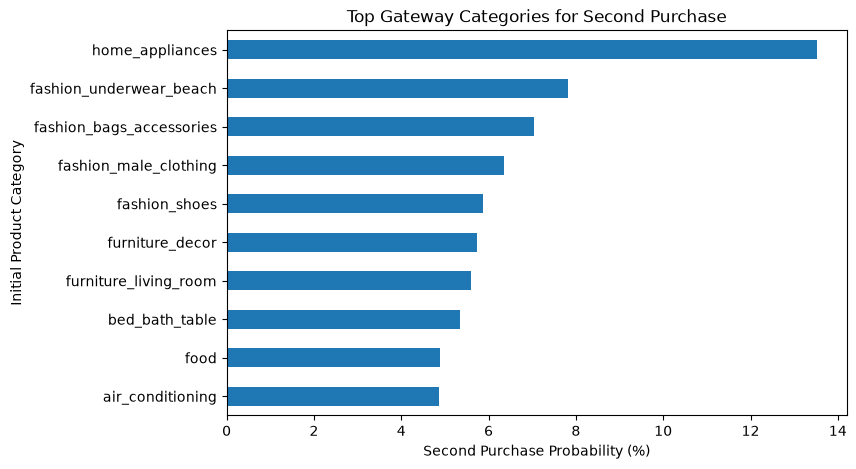

In [247]:
gateway_filtered.nlargest(10).sort_values().plot(
    kind='barh',
    figsize=(8, 5)
)

plt.xlabel('Second Purchase Probability (%)')
plt.ylabel('Initial Product Category')
plt.title('Top Gateway Categories for Second Purchase')
plt.show()